In [3]:
!pip install typeguard==4.0.1


In [5]:
!pip install -q tensorflow tensorflow-addons

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import glob
import numpy as np
import matplotlib.pyplot as plt


In [32]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 16
SEED = 42
directory = "/kaggle/input/wheat-leaf-diseases/Wheat Leaf Diseases Dataset From Bangladesh"

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    directory,
    validation_split=0.1,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Get class names and number of classes
class_names = train_dataset.class_names
num_classes = len(class_names)


Found 3781 files belonging to 3 classes.
Using 3403 files for training.
Found 3781 files belonging to 3 classes.
Using 378 files for validation.


In [33]:
data_imbalance = [len(glob.glob(os.path.join(directory, class_folder, '*.*'))) for class_folder in class_names]
total_images = sum(data_imbalance)

class_weight = {
    i: (1.0 / count) * (total_images / len(data_imbalance))
    for i, count in enumerate(data_imbalance)
}


In [34]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

def augment_image(image, label):
    image = data_augmentation(image)
    return image, label

def preprocess_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # Normalize the images
    return image, label


In [35]:
train_dataset = train_dataset.map(augment_image).map(preprocess_image)
val_dataset = val_dataset.map(preprocess_image)  # No augmentation for validation set

# Prefetch the datasets for better performance
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


In [36]:
def conv_embedding(x, filters, kernel_size=3, strides=1, name="conv_embed"):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same', name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("gelu", name=f"{name}_gelu")(x)
    return x


def transformer_encoder(x, num_heads, projection_dim, dropout=0.1, name="transformer"):
    # Layer Normalization
    x1 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln1")(x)
    
    # Multi-Head Attention
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=projection_dim,
        dropout=dropout,
        name=f"{name}_mha"
    )(x1, x1)
    x2 = layers.Add(name=f"{name}_skip1")([x, attention_output])

    # Feed Forward Network
    x3 = layers.LayerNormalization(epsilon=1e-6, name=f"{name}_ln2")(x2)
    ffn = keras.Sequential([
        layers.Dense(projection_dim * 4, activation="gelu"),
        layers.Dense(projection_dim),
    ], name=f"{name}_ffn")
    
    ffn_output = ffn(x3)
    x4 = layers.Add(name=f"{name}_skip2")([x2, ffn_output])
    return x4


In [38]:
def create_cvt_model(input_shape=(224, 224, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    
    # Stage 1
    x = conv_embedding(inputs, filters=64, strides=2, name="stage1_embed")
    x = transformer_encoder(x, num_heads=1, projection_dim=64, name="stage1_transformer")

    # Stage 2
    x = conv_embedding(x, filters=128, strides=2, name="stage2_embed")
    x = transformer_encoder(x, num_heads=2, projection_dim=128, name="stage2_transformer")

    # Stage 3
    x = conv_embedding(x, filters=256, strides=2, name="stage3_embed")
    x = transformer_encoder(x, num_heads=4, projection_dim=256, name="stage3_transformer")

    # Global Pooling and Classification
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

    model = keras.Model(inputs, outputs, name="CvT")
    return model


In [39]:
model = create_cvt_model(input_shape=(160, 160, 3), num_classes=num_classes)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "CvT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20            │ (None, 160, 160, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_conv         │ (None, 80, 80, 64)     │          1,792 │ input_layer_20[0][0]   │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_bn           │ (None, 80, 80, 64)     │            256 │ stage1_embed_conv[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_embed_gelu         │ (None, 80, 80, 64)     │              0 │ stage1_embed_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_transformer_ln1    │ (None, 80, 80, 64)     │            128 │ stage1_embed_gelu[0][… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_transformer_mha    │ (None, 80, 80, 64)     │         16,640 │ stage1_transformer_ln… │
│ (MultiHeadAttention)      │                        │                │ stage1_transformer_ln… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_transformer_skip1  │ (None, 80, 80, 64)     │              0 │ stage1_embed_gelu[0][… │
│ (Add)                     │                        │                │ stage1_transformer_mh… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_transformer_ln2    │ (None, 80, 80, 64)     │            128 │ stage1_transformer_sk… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_transformer_ffn    │ (None, 80, 80, 64)     │         33,088 │ stage1_transformer_ln… │
│ (Sequential)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage1_transformer_skip2  │ (None, 80, 80, 64)     │              0 │ stage1_transformer_sk… │
│ (Add)                     │                        │                │ stage1_transformer_ff… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage2_embed_conv         │ (None, 40, 40, 128)    │         73,856 │ stage1_transformer_sk… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage2_embed_bn           │ (None, 40, 40, 128)    │            512 │ stage2_embed_conv[0][… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stage2_embed_gelu         │ (None, 40, 40, 128)    │              0 │ stage2_embed_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├──────────────────────

 Total params: 2,266,051 (8.64 MB)

 Trainable params: 2,265,155 (8.64 MB)

 Non-trainable params: 896 (3.50 KB)

In [40]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight,  # Include class weights here
    callbacks=[
        keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(patience=2)
    ]
)


Epoch 1/10


I0000 00:00:1745246956.341494     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


213/213 ━━━━━━━━━━━━━━━━━━━━ 109s 381ms/step - accuracy: 0.8162 - loss: 0.4802 - val_accuracy: 0.2513 - val_loss: 4.4507 - learning_rate: 1.0000e-04
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 292ms/step - accuracy: 0.9300 - loss: 0.1968 - val_accuracy: 0.5370 - val_loss: 2.7630 - learning_rate: 1.0000e-04
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 291ms/step - accuracy: 0.9415 - loss: 0.1626 - val_accuracy: 0.9550 - val_loss: 0.0979 - learning_rate: 1.0000e-04
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 292ms/step - accuracy: 0.9597 - loss: 0.1132 - val_accuracy: 0.9815 - val_loss: 0.0411 - learning_rate: 1.0000e-04
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 291ms/step - accuracy: 0.9559 - loss: 0.1109 - val_accuracy: 0.9788 - val_loss: 0.0621 - learning_rate: 1.0000e-04
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 291ms/step - accuracy: 0.9699 - loss: 0.0833 - val_accuracy: 0.9841 - val_loss: 0.0438 - learning_rate: 1.0000e-04
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 62s 291ms/step -

In [41]:
test_loss, test_acc = model.evaluate(val_dataset)
print(f"Validation Accuracy: {test_acc:.2f}")


24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9837 - loss: 0.0491
Validation Accuracy: 0.99


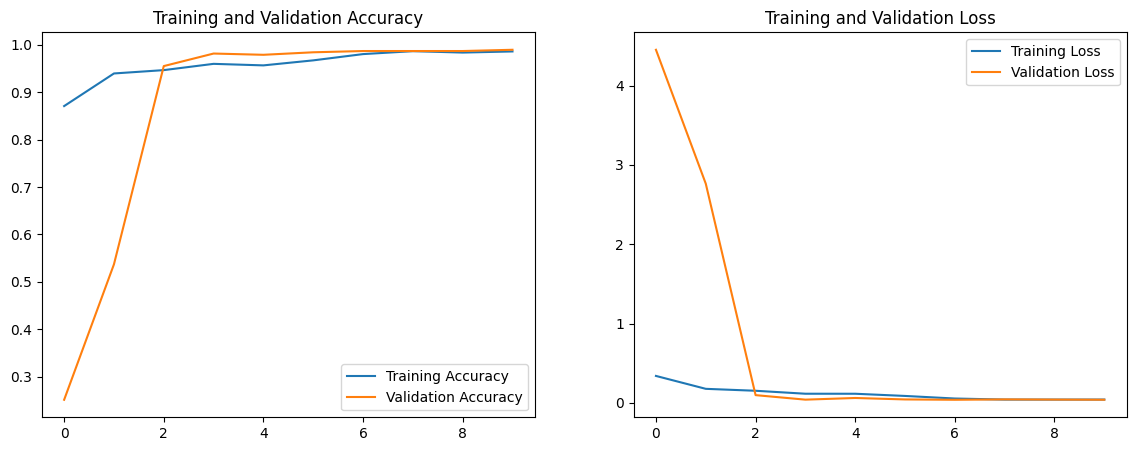

In [42]:
def plot_training(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.legend(loc="lower right")
    plt.title("Training and Validation Accuracy")

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.legend(loc="upper right")
    plt.title("Training and Validation Loss")
    plt.show()

plot_training(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


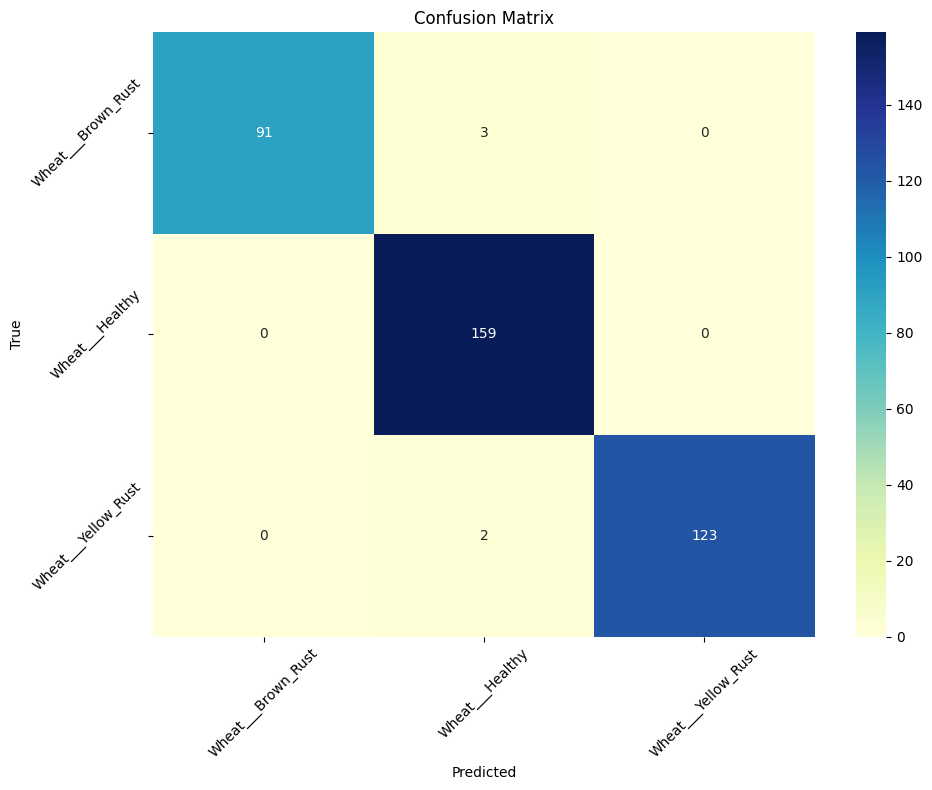


Classification Report:

                     precision    recall  f1-score   support

 Wheat___Brown_Rust       1.00      0.97      0.98        94
    Wheat___Healthy       0.97      1.00      0.98       159
Wheat___Yellow_Rust       1.00      0.98      0.99       125

           accuracy                           0.99       378
          macro avg       0.99      0.98      0.99       378
       weighted avg       0.99      0.99      0.99       378



In [45]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# Get predictions
y_true = []
y_pred = []

for images, labels in val_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))
